5.1

In [3]:
import pandas as pd

df = pd.read_csv(
    "grades.csv",
    encoding="utf-8-sig",
    sep=";",
)

print(df.columns)

Index(['Vurderingsfagkode', 'Fagnavn', 'Skolenavn',
       '2024-25.Skriftlig eksamen. Snittkarakter', '2024-25.Skriftlig eksamen',
       '2024-25.Standpunkt. Snittkarakter', '2024-25.Standpunkt'],
      dtype='str')


5.2

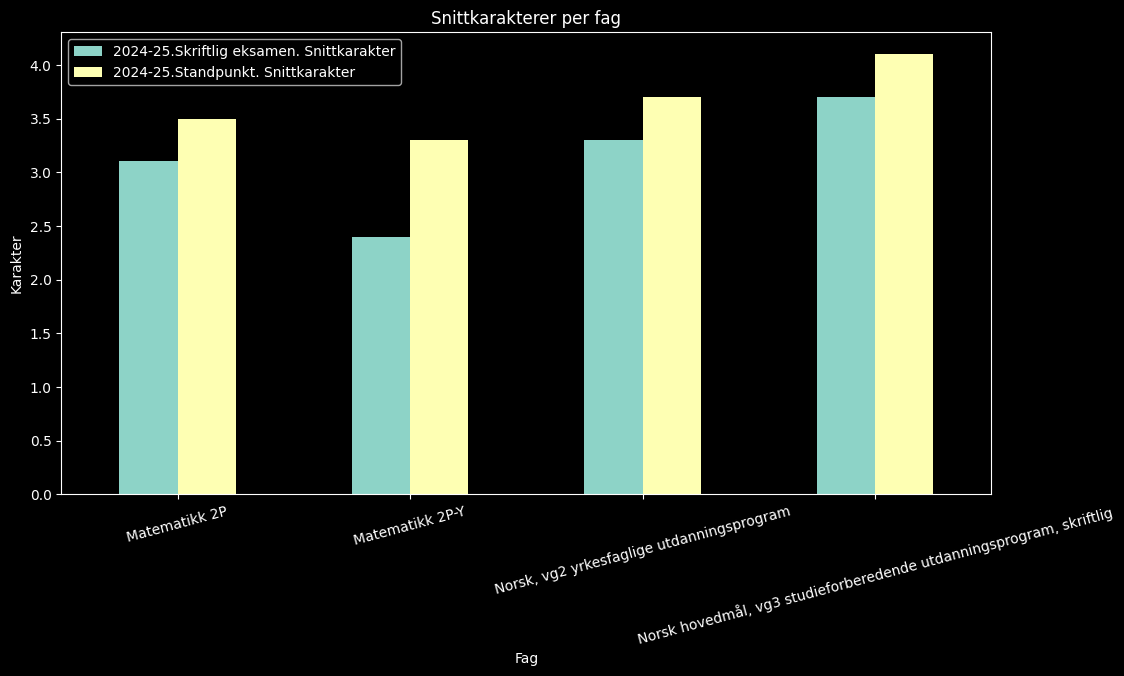

In [40]:
import matplotlib.pyplot as plt

df = df[df["Skolenavn"] == "Alle skoler"]

fag = [
    "Matematikk 2P",
    "Matematikk 2P-Y",
    "Norsk, vg2 yrkesfaglige utdanningsprogram",
    "Norsk hovedmål, vg3 studieforberedende utdanningsprogram, skriftlig"
]

df = df[df["Fagnavn"].isin(fag)]

df["2024-25.Skriftlig eksamen. Snittkarakter"] = (
    df["2024-25.Skriftlig eksamen. Snittkarakter"]
    .astype(str)
    .str.replace(",", ".")
)

df["2024-25.Standpunkt. Snittkarakter"] = (
    df["2024-25.Standpunkt. Snittkarakter"]
    .astype(str)
    .str.replace(",", ".")
)

df["2024-25.Skriftlig eksamen. Snittkarakter"] = pd.to_numeric(
    df["2024-25.Skriftlig eksamen. Snittkarakter"],
    errors="coerce"
)

df["2024-25.Standpunkt. Snittkarakter"] = pd.to_numeric(
    df["2024-25.Standpunkt. Snittkarakter"],
    errors="coerce"
)

df.plot(
    x="Fagnavn",
    y=[
        "2024-25.Skriftlig eksamen. Snittkarakter",
        "2024-25.Standpunkt. Snittkarakter"
    ],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Snittkarakterer per fag")
plt.xlabel("Fag")
plt.ylabel("Karakter")

plt.xticks(rotation=15)

plt.show()


In our dataset, we chose two subjects from the general academic track and two from vocational education. For both tracks, we selected the subjects Norwegian written and Mathematics (2P). We made this choice because we wanted to examine differences in average grades and final (standpunkt) grades, but also to compare differences between general academic and vocational education.

After creating a clustered column chart, we observe that the claim that the average grade for final assessments is higher than the exam average holds true, regardless of educational track and subject. Mathematics, which is a more formula-based subject, generally has a lower average than Norwegian, which is a more essay-based and analytical subject. We also see that students in the general academic track tend to achieve higher averages in these two subjects compared to those in vocational education.

5.3


Problemstilling: «Er det systematiske forskjeller i karakterer mellom fellesfag og programfag for yrkesfagselever, og hva kan dette si om faglig motivasjon og vurderingspraksis?»

In [2]:

dataset = pd.read_csv(
    "YRKEGRADES.csv",
    encoding="utf-8-sig",
    sep=";",
)

print(dataset.columns)

Index(['Vurderingsfagkode', 'Vurderingsfagnavn', 'EnhetNavn',
       '2022-23.Muntlig eksamen Snittkarakter',
       '2022-23.Muntlig eksamen Antall elever',
       '2022-23.Skriftlig eksamen Snittkarakter',
       '2022-23.Skriftlig eksamen Antall elever',
       '2022-23.Standpunkt Snittkarakter', '2022-23.Standpunkt Antall elever',
       '2023-24.Muntlig eksamen Snittkarakter',
       '2023-24.Muntlig eksamen Antall elever',
       '2023-24.Skriftlig eksamen Snittkarakter',
       '2023-24.Skriftlig eksamen Antall elever',
       '2023-24.Standpunkt Snittkarakter', '2023-24.Standpunkt Antall elever',
       '2024-25.Muntlig eksamen Snittkarakter',
       '2024-25.Muntlig eksamen Antall elever',
       '2024-25.Skriftlig eksamen Snittkarakter',
       '2024-25.Skriftlig eksamen Antall elever',
       '2024-25.Standpunkt Snittkarakter', '2024-25.Standpunkt Antall elever'],
      dtype='str')


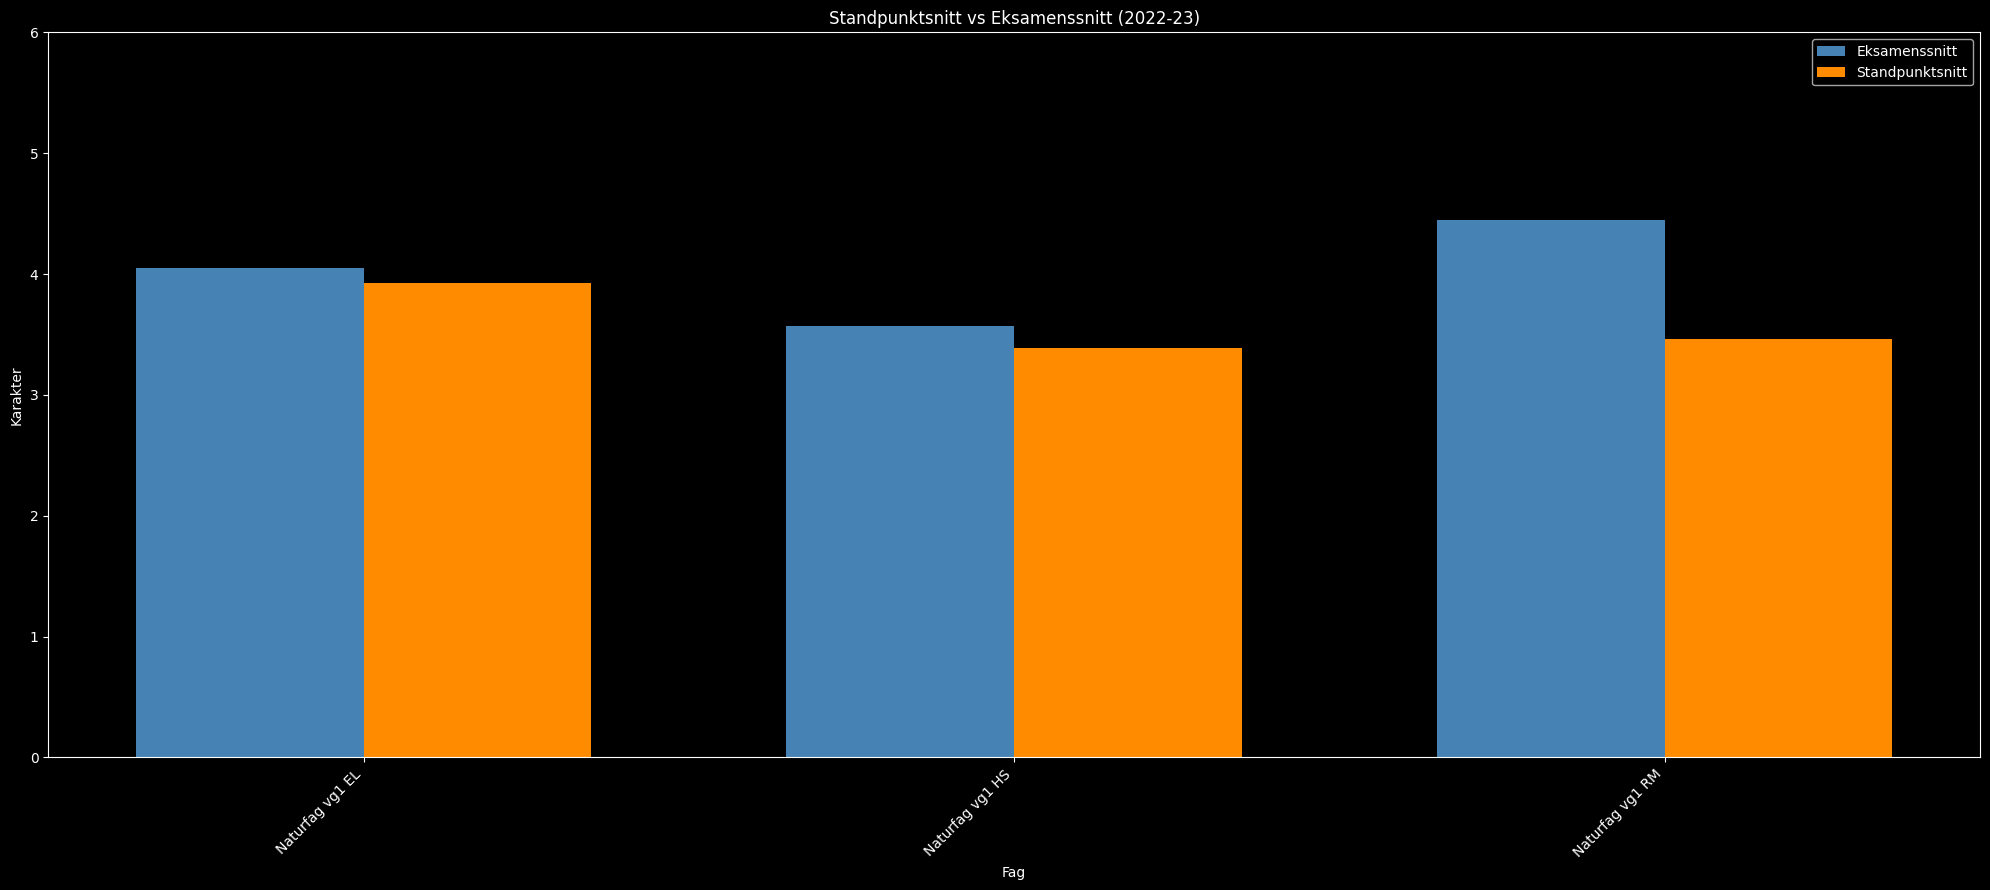

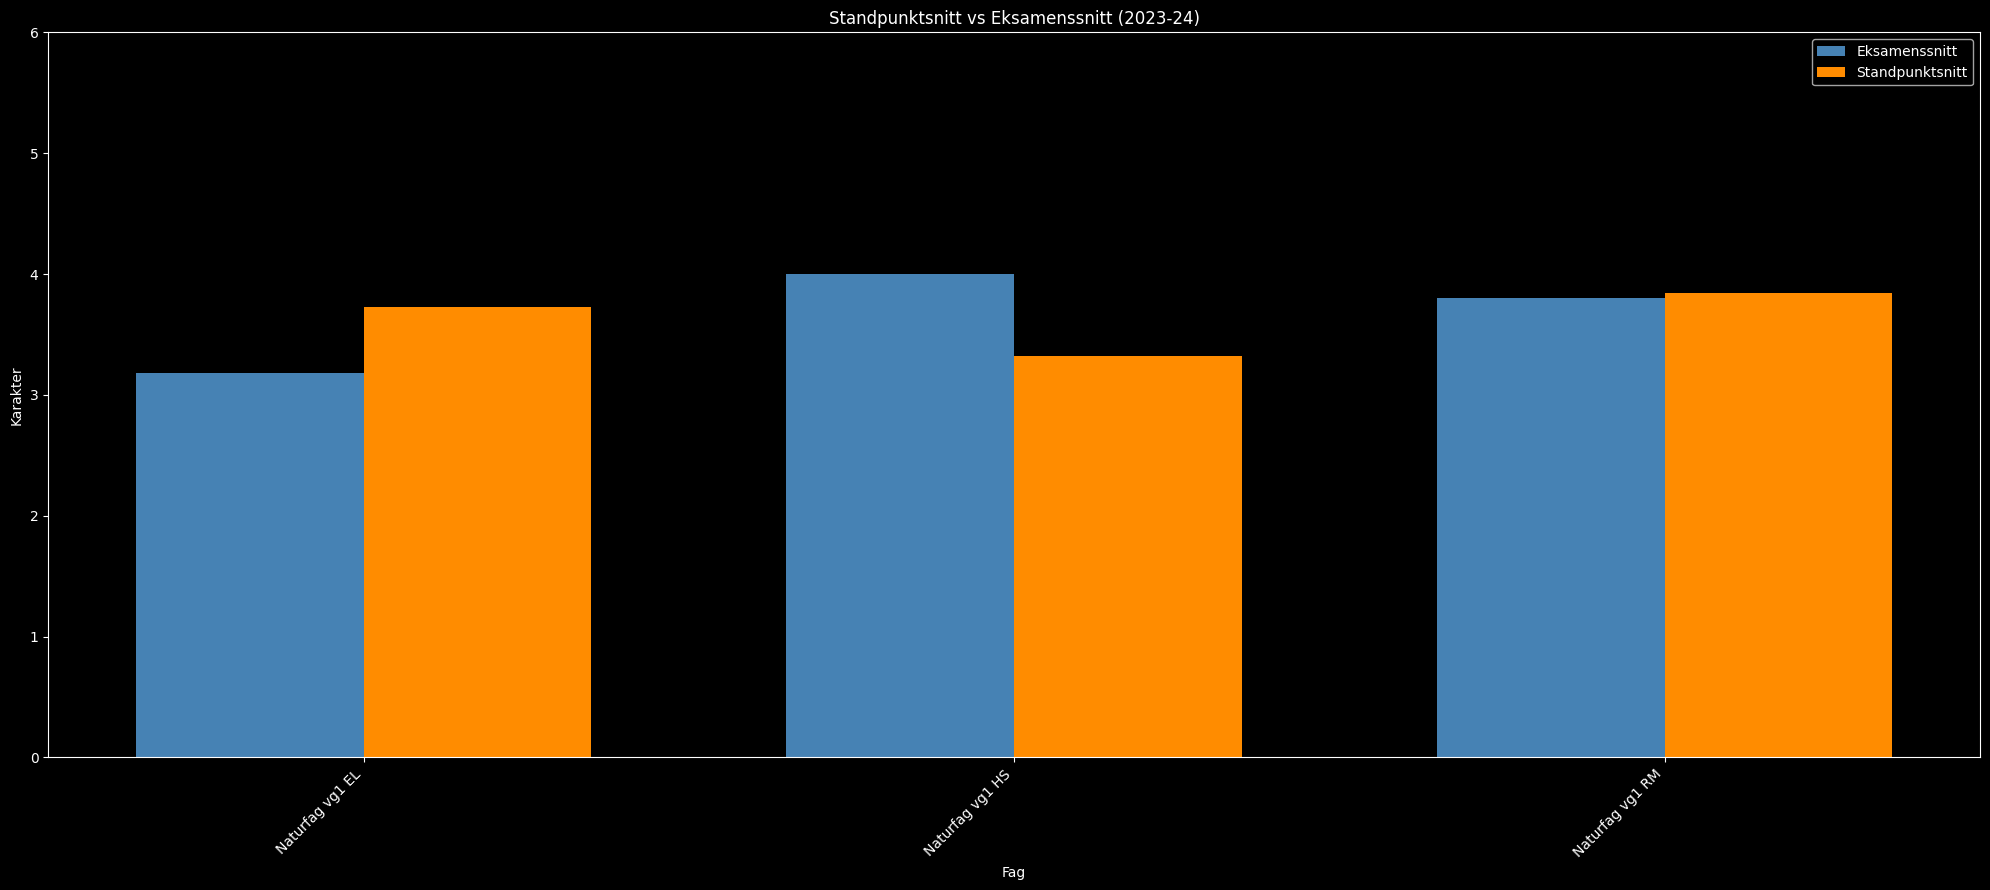

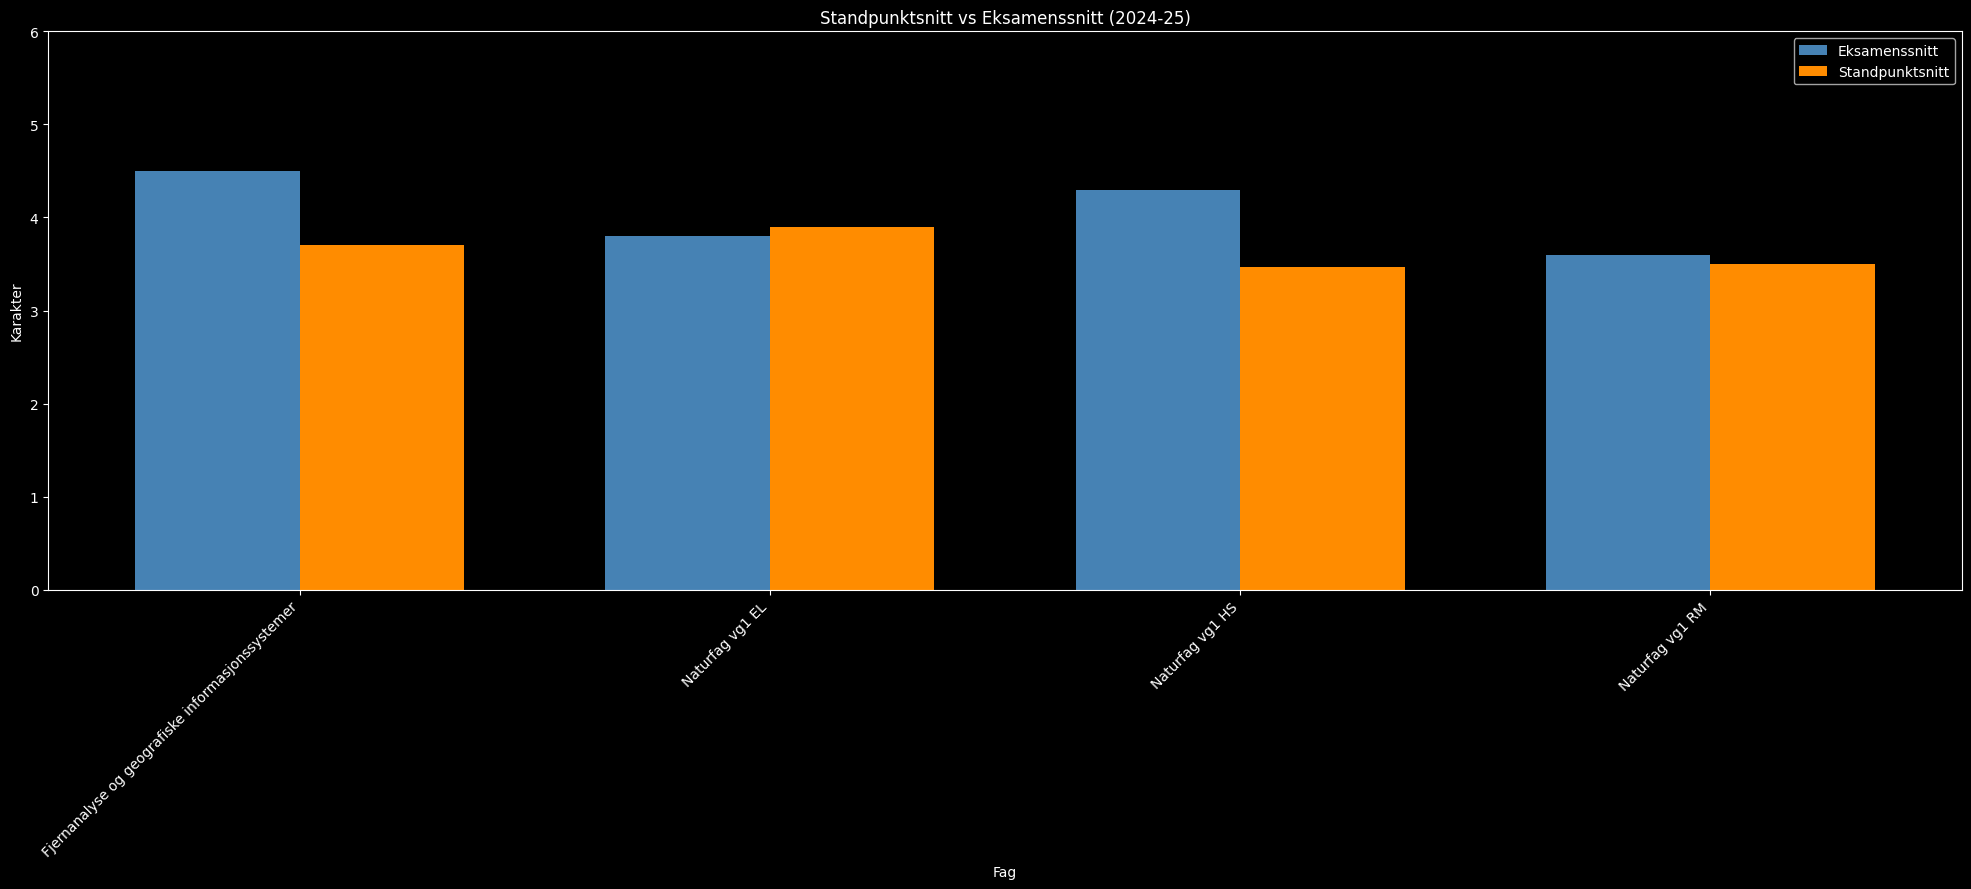

In [9]:
import numpy as np

fag_col = "Vurderingsfagnavn"
years = ["2022-23", "2023-24", "2024-25"]

for year in years:

    exam_col = f"{year}.Muntlig eksamen Snittkarakter"
    stand_col = f"{year}.Standpunkt Snittkarakter"

    # Velg kolonner
    temp = df[[fag_col, exam_col, stand_col]].copy()

    # Gjør om komma til punktum og konverter til tall
    for col in [exam_col, stand_col]:

        temp[col] = (
            temp[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )

        temp[col] = pd.to_numeric(
            temp[col],
            errors="coerce"
        )

    # Fjern tomme fag
    temp = temp.dropna(subset=[fag_col])

    # Gruppér per fag og finn snitt
    temp = (
        temp.groupby(fag_col, as_index=False)[[exam_col, stand_col]]
        .mean()
    )

    # Fjern fag med manglende eller 0 verdier
    temp = temp[
        (temp[exam_col] > 0) &
        (temp[stand_col] > 0)
    ]

    # Sorter alfabetisk
    temp = temp.sort_values(by=fag_col)

    # Clustered chart
    x = np.arange(len(temp[fag_col]))
    width = 0.35

    fig, ax = plt.subplots(figsize=(20, 9))

    # Eksamen
    ax.bar(
        x - width/2,
        temp[exam_col],
        width,
        label="Eksamenssnitt",
        color="steelblue"
    )

    # Standpunkt
    ax.bar(
        x + width/2,
        temp[stand_col],
        width,
        label="Standpunktsnitt",
        color="darkorange"
    )

    # Akser og tekst
    ax.set_xticks(x)
    ax.set_xticklabels(
        temp[fag_col],
        rotation=45,
        ha="right"
    )

    ax.set_ylabel("Karakter")
    ax.set_xlabel("Fag")
    ax.set_title(f"Standpunktsnitt vs Eksamenssnitt ({year})")

    ax.set_ylim(0, 6)

    ax.legend()

    plt.tight_layout()

    # Vis clustered bar chart
    plt.show()